In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('datasets/wine-clustering.csv')

In [3]:
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [4]:
data.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

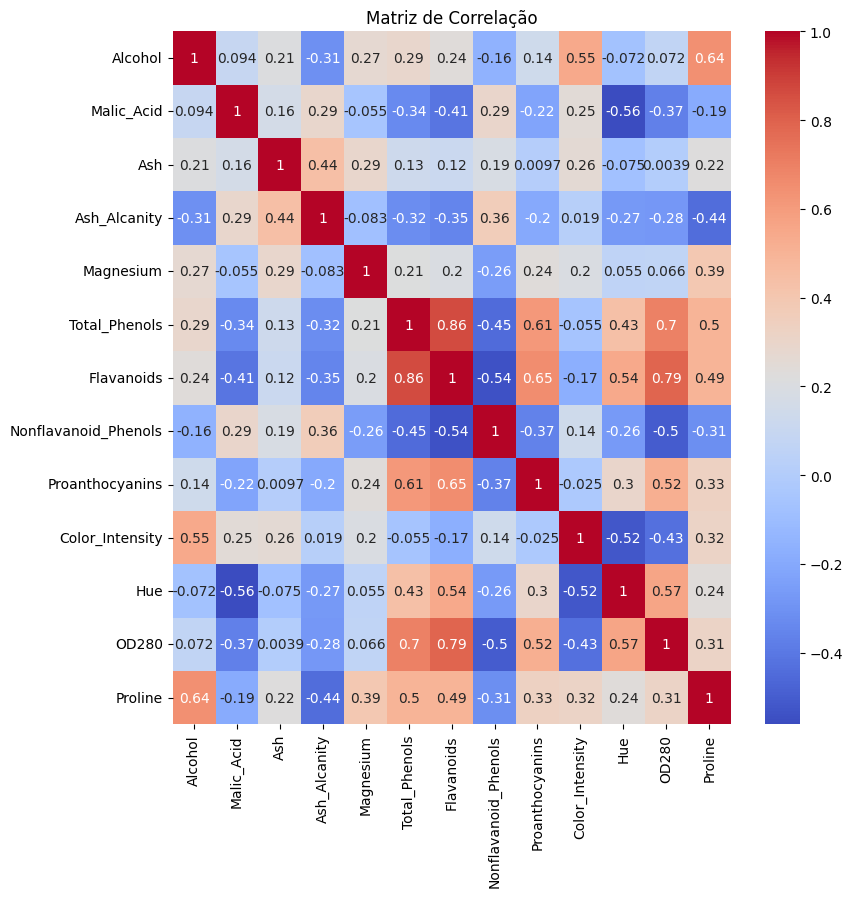

In [5]:
# Mapa de calor da correlação
plt.figure(figsize=(9, 9))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()


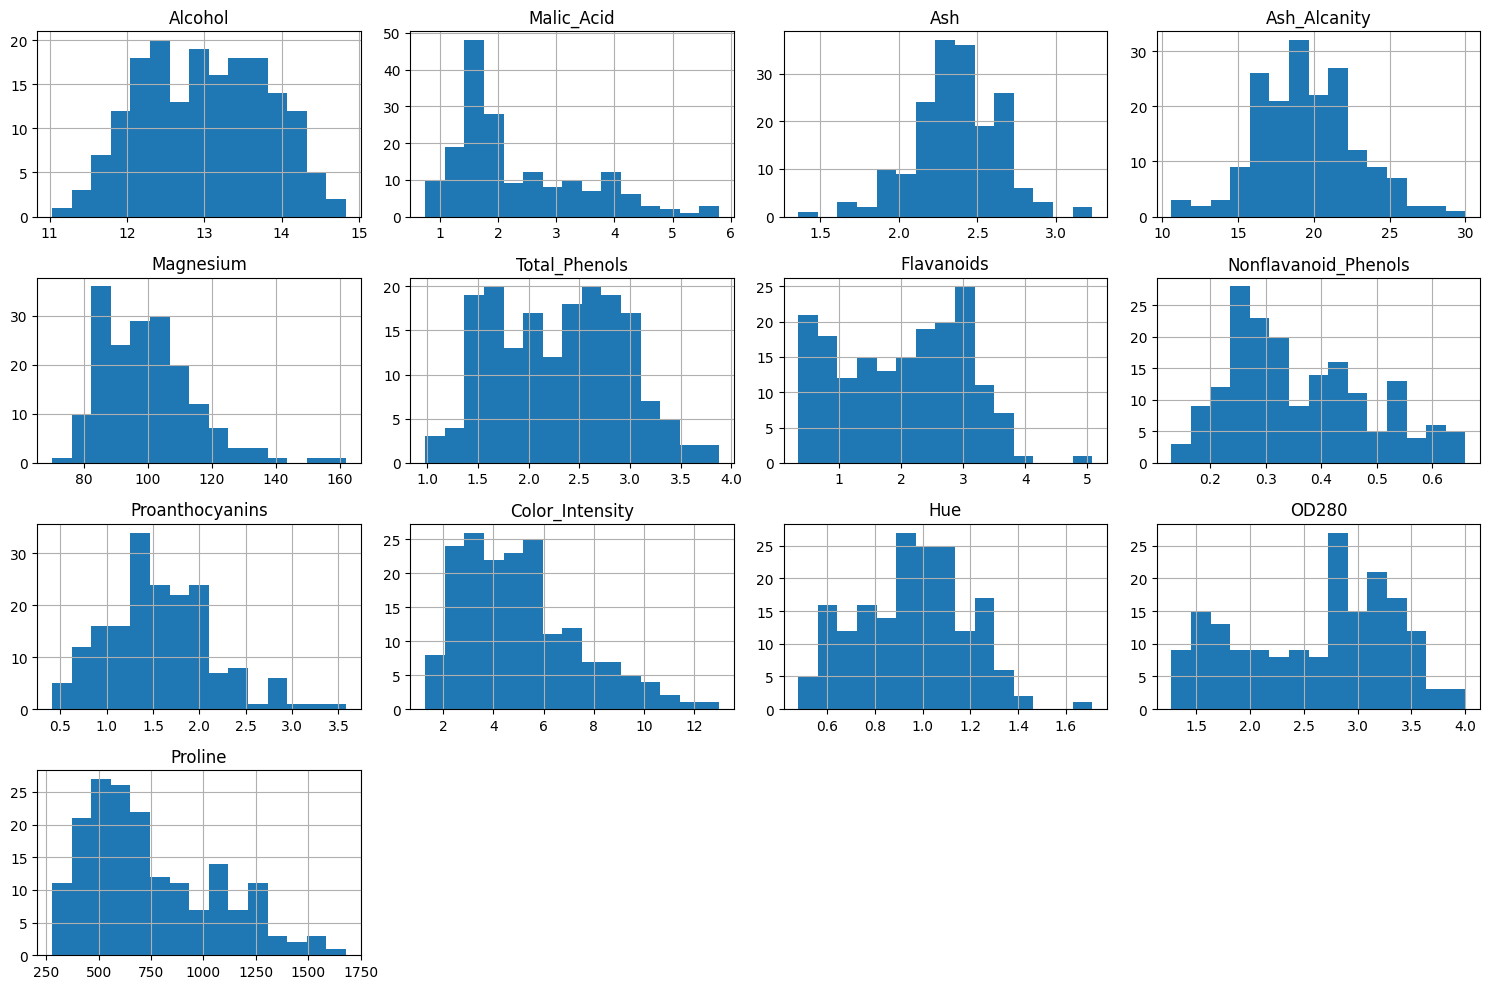

In [6]:
data.hist(bins=15, figsize=(15, 10), layout=(4, 4))
plt.tight_layout()
plt.show()

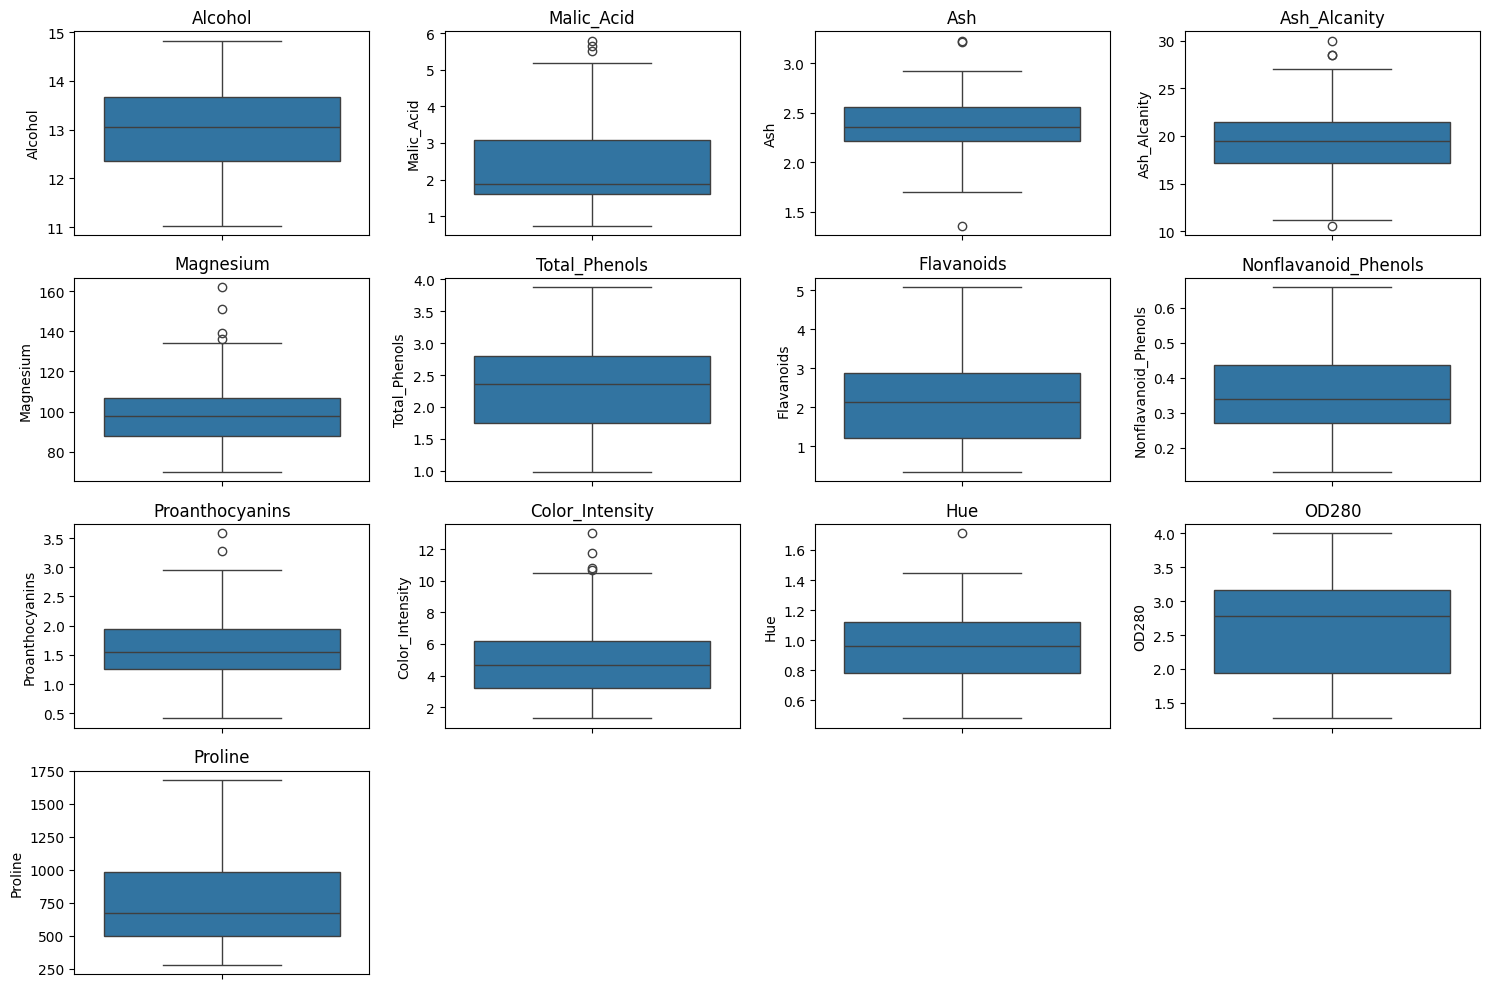

In [7]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(data.columns):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

#Malic_Acid, Ash, Ash_Alcanity, Magnesium, Proanthocyanins, Color_Intensity, Hue possuem outliers bem expressivos.  

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [9]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Visualizar a variância explicada
print("Variância explicada:", np.round(pca.explained_variance_ratio_, 3))

Variância explicada: [0.998 0.002]


K-MEANS

In [10]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_scaled)
labels_kmeans = kmeans.labels_

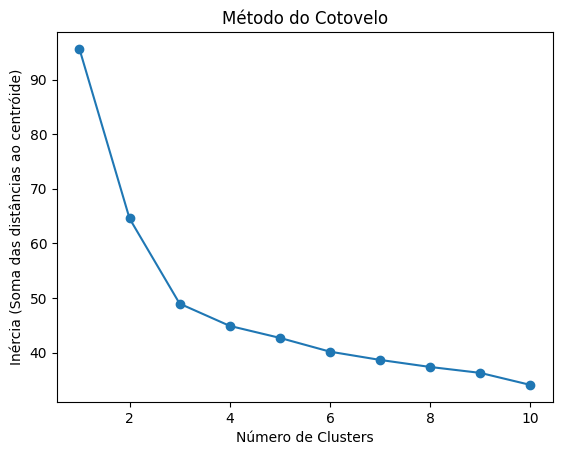

In [11]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(data_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia (Soma das distâncias ao centróide)')
plt.show()

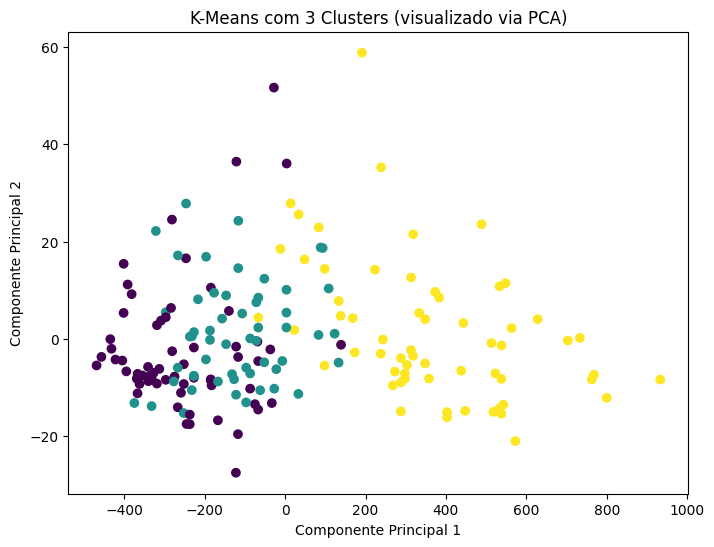

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels_kmeans, cmap='viridis')
plt.title('K-Means com 3 Clusters (visualizado via PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(data_scaled, labels_kmeans)
print(f"Índice de Silhueta (K-Means): {silhouette:.3f}")

Índice de Silhueta (K-Means): 0.301


In [14]:
inercia = kmeans.inertia_
print(f"Variância Intracluster (Inércia): {inercia:.2f}")

Variância Intracluster (Inércia): 48.96


In [15]:
from sklearn.neighbors import kneighbors_graph
import numpy as np

def conectividade(data, labels, k=10):
    connectivity_matrix = kneighbors_graph(data, k, mode='connectivity', include_self=False)
    connectivity = 0.0
    for i in range(data.shape[0]):
        neighbors = connectivity_matrix[i].nonzero()[1]
        for j in neighbors:
            if labels[i] != labels[j]:
                connectivity += 1
    return connectivity

conect = conectividade(data_scaled, labels_kmeans)
print(f"Conectividade (K-Means): {conect}")

Conectividade (K-Means): 111.0


CLUSTERING HIERÁRQUICO

In [16]:
from sklearn.cluster import AgglomerativeClustering
#Complete foi a melhor dos 3
hierarchical = AgglomerativeClustering(n_clusters=2, linkage='complete')
labels_hier = hierarchical.fit_predict(data_scaled)

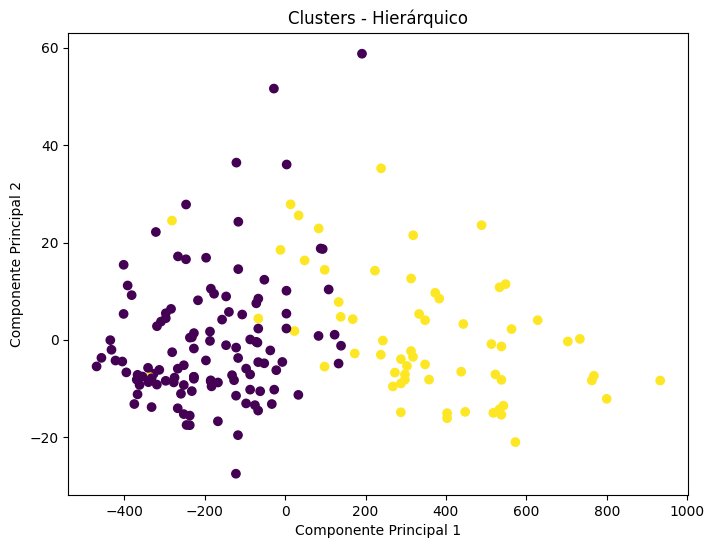

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels_hier, cmap='viridis')
plt.title('Clusters - Hierárquico')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

In [18]:
# Silhueta
silhouette_hier = silhouette_score(data_scaled, labels_hier)
print(f"Silhueta (Hierárquico): {silhouette_hier:.3f}")

# Conectividade
conect_hier = conectividade(data_scaled, labels_hier)
print(f"Conectividade (Hierárquico): {conect_hier}")

Silhueta (Hierárquico): 0.257
Conectividade (Hierárquico): 70.0


DBSCAN

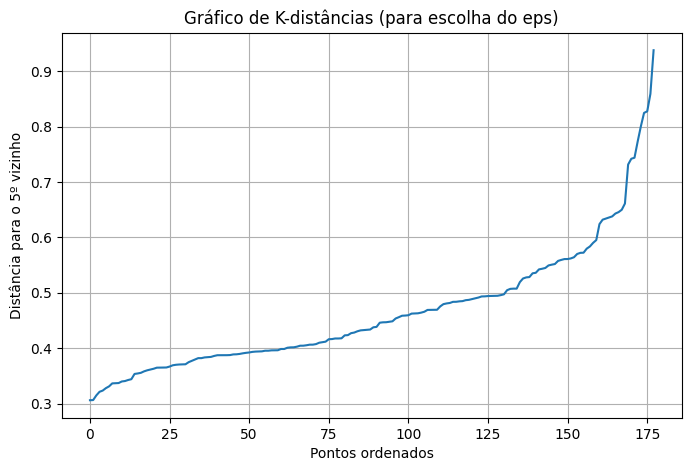

In [19]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(data_scaled)
distances, indices = neighbors_fit.kneighbors(data_scaled)

distances = np.sort(distances[:, k-1])
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("Gráfico de K-distâncias (para escolha do eps)")
plt.xlabel("Pontos ordenados")
plt.ylabel(f"Distância para o {k}º vizinho")
plt.grid()
plt.show()

In [31]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=8)
labels_dbscan = dbscan.fit_predict(data_scaled)

In [32]:
import numpy as np

labels, counts = np.unique(labels_dbscan, return_counts=True)
print("Labels encontrados:", labels)
print("Contagem por label:", counts)


Labels encontrados: [-1  0  1]
Contagem por label: [ 29 101  48]


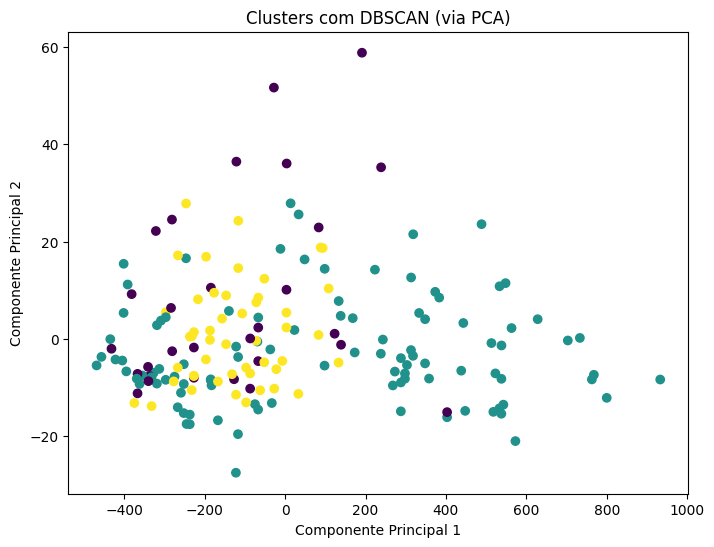

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels_dbscan, cmap='viridis')
plt.title('Clusters com DBSCAN (via PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

In [36]:
import numpy as np

def calcular_inercia(data, labels):
    inercia = 0
    for label in np.unique(labels):
        cluster_points = data[labels == label]
        centroide = cluster_points.mean(axis=0)
        inercia += np.sum((cluster_points - centroide) ** 2)
    return inercia


In [37]:
mask = labels_dbscan != -1
data_db = data_scaled[mask]
labels_db = labels_dbscan[mask]

sil_db = silhouette_score(data_db, labels_db)
inercia_db = calcular_inercia(data_db, labels_db)
conect_db = conectividade(data_db, labels_db)

print(f"Silhueta (DBSCAN): {sil_db:.3f}")
print(f"Inércia (DBSCAN): {inercia_db:.2f}")
print(f"Conectividade (DBSCAN): {conect_db}")


Silhueta (DBSCAN): 0.346
Inércia (DBSCAN): 46.59
Conectividade (DBSCAN): 24.0
